In [2]:
import numpy as np

In [56]:
import numpy as np

def cf_shell(label="shell",
             total_time=20,
             time_step=0.25/30,
             b=0.1, d=4, z=0, a=1, phi=0, psi=0,
             n=0, n_amp=0,
             c=0, c_amp=0,
             k=0, 
             points_on_aperture=40,
             length=1,
             smooth=True 
             ):
    
    # Number of time steps
    num_timesteps = int(total_time / time_step) + 1
    # Array to hold the matrices for each time step and theta
    results = np.zeros((num_timesteps, points_on_aperture, 3))
    
    thetas = np.linspace(0, 2 * np.pi, points_on_aperture, endpoint=False)

    for i, t in enumerate(np.linspace(0, total_time, num_timesteps)):
        sin_t = np.sin(t)
        cos_t = np.cos(t)
        axial_term = 1 + c_amp * np.sin(c * t)
        
        # Rotation matrix based on psi
        R = np.array([[np.cos(psi), -np.sin(psi), 0],
                      [np.sin(psi),  np.cos(psi), 0],
                      [0,            0,           1]])

        for j, theta in enumerate(thetas):
            spiral_term = 1 + n_amp * np.sin(n * theta)
            
            # Normal and Binormal vectors at this theta
            _N = np.array([
                b * cos_t - sin_t,
                -b * sin_t - cos_t,
                0
            ]) / np.sqrt(b**2 + 1)

            _B = np.array([
                b * z * (b * sin_t + cos_t),
                b * z * (b * cos_t - sin_t),
                d * (b**2 + 1)
            ]) / np.sqrt((b**2 + 1) * ((b**2 + 1) * (d**2) + (b**2) * (z**2)))

            # Compute the transformation for current t and theta
            vector_combination = np.array([
                (a * np.sin(theta) * np.cos(phi) + np.cos(theta) * np.sin(phi)) * spiral_term * _N +
                (a * np.sin(theta) * np.sin(phi) - np.cos(theta) * np.cos(phi) + k) * spiral_term * _B
            ])

            rotated_points = np.matmul(R, vector_combination.T).T
            results[i, j, :] = axial_term * (np.exp(b * t) - (1 / (t + 1))) * rotated_points

    return results



(21, 40, 3)


In [70]:
# Assume cf_shell outputs a 2400 x 80 x 3 tensor
data = cf_shell(b=0.06, z=5, points_on_aperture=1)


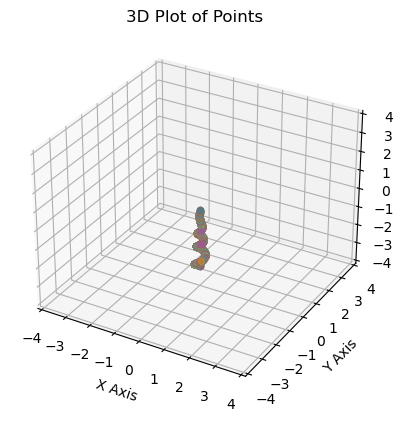

In [71]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming 'data' is your actual data array with shape (21, 40, 3)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot each point in each matrix
for matrix in data:
    x, y, z = matrix[:, 0], matrix[:, 1], matrix[:, 2]
    ax.scatter(x, y, z, alpha=0.6)  # Plot each (x, y, z) coordinate

# Set the limits for the axes
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_zlim(-4, 4)

# Labels for axes
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

# Title and show the plot
ax.set_title('3D Plot of Points')
plt.show()
